# SALES DATA ANALYSIS
## AI Academia — Python with Data Science Internship

**Name:** Shubham Carpenter  
**Date:** 15.10.2026

This project analyses retail sales data to identify seasonal trends, top products, and predict sales using machine learning models.

## Section 1 — Data Loading

This notebook contains a demo sales dataset for learning data analysis with Python and Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
print(df.shape)

(30, 7)


In [4]:
print(df.columns.tolist())

['Date', 'Product', 'Category', 'Quantity', 'Price', 'Total_Sales', 'Region']


In [5]:
df.head()

,Date,Product,Category,Quantity,Price,Total_Sales,Region
0,2026-01-05,Laptop,Electronics,2,55000,110000,North
1,2026-01-07,Mouse,Electronics,5,800,4000,West
2,2026-01-10,Chair,Furniture,3,4500,13500,South
3,2026-01-12,Keyboard,Electronics,4,1500,6000,East
4,2026-01-15,Desk,Furniture,2,8500,17000,North


## Column Explanation

- Date: The date on which the sale happened.
- Product: The name of the product sold.
- Category: The category to which the product belongs.
- Quantity: The number of units sold.
- Price: The price of one unit of the product.
- Total_Sales: The total revenue generated from the sale.
- Region: The region where the sale happened.

## Section 2 - Data Cleaning

In [6]:
print("Before cleaning:", df.shape)

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Before cleaning: (30, 7)
Date           0
Product        0
Category       0
Quantity       0
Price          0
Total_Sales    0
Region         0
dtype: int64
Duplicates: 0


In [7]:
# Duplicate remove and Date fix

df_clean = df.drop_duplicates().copy()

df_clean['Date'] = pd.to_datetime(df_clean['Date'])

In [8]:
# Clean Sales Column

df_clean['Total_Sales'] = pd.to_numeric(
    df_clean['Total_Sales'], errors='coerce'
)

df_clean['Total_Sales'] = df_clean['Total_Sales'].fillna(
    df_clean['Total_Sales'].median()
)

df_clean.dropna(subset=['Date'], inplace=True)

In [9]:
print("After cleaning:", df_clean.shape)
df_clean.info()

After cleaning: (30, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         30 non-null     datetime64[ns]
 1   Product      30 non-null     object        
 2   Category     30 non-null     object        
 3   Quantity     30 non-null     int64         
 4   Price        30 non-null     int64         
 5   Total_Sales  30 non-null     int64         
 6   Region       30 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 1.8+ KB


### Issues Found and Fixes

1. Missing values:
   No missing values were found in the dataset.

2. Duplicate rows:
   No duplicate rows were found.

3. Date data type:
   The Date column was converted to datetime format using pd.to_datetime().

4. Total_Sales data type:
   The Total_Sales column was converted to numeric format using pd.to_numeric().

5. Invalid or missing Total_Sales values:
   Any invalid values would be converted to NaN and filled using the median value.

6. Missing Date values:
   Rows with missing Date values were removed.

### Final Result

Before cleaning: 30 rows
After cleaning: 30 rows
Final dataset: df_clean

## Section 3 - Numpy Statistics

In [10]:
sales_arr = df_clean['Total_Sales'].to_numpy()

print('Mean:   ', round(np.mean(sales_arr), 2))
print('Median: ', round(np.median(sales_arr), 2))
print('Std Dev:', round(np.std(sales_arr), 2))
print('Total:  ', round(np.sum(sales_arr), 2))

Mean:    25006.67
Median:  12000.0
Std Dev: 35314.26
Total:   750200


In [11]:
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
monthly = df_clean.groupby('Month')['Total_Sales'].sum()

print('Top 3 months:')
print(monthly.sort_values(ascending=False).head(3))

print('Bottom 3 months:')
print(monthly.sort_values().head(3))

Top 3 months:
Month
2026-03    327200
2026-01    254200
2026-02    168800
Freq: M, Name: Total_Sales, dtype: int64
Bottom 3 months:
Month
2026-02    168800
2026-01    254200
2026-03    327200
Freq: M, Name: Total_Sales, dtype: int64


### Summary

The average sale amount is 25006.67
The median sale amount is 12000.0
The best month is March because it has the highest total sales.
The lowest sales month is February because it has the smallest total sales of 168800.

## Section 4 — Matplotlib Charts

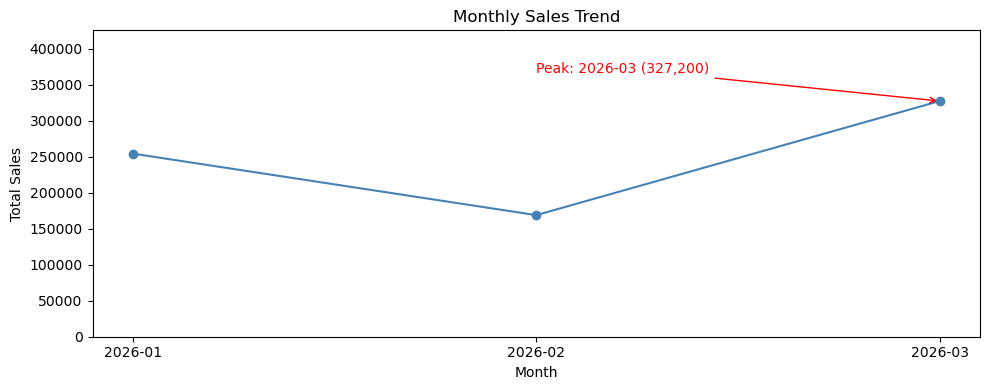

In [12]:
monthly = df_clean.groupby("Month")["Total_Sales"].sum()

peak_month = monthly.idxmax()
peak_value = monthly.max()
peak_index = monthly.values.argmax()

x_positions = np.arange(len(monthly))
month_labels = monthly.index.astype(str)

plt.figure(figsize=(10, 4))
plt.plot(x_positions, monthly.values, color="steelblue", marker="o")
plt.xticks(x_positions, month_labels)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.annotate(
    f"Peak: {peak_month} ({peak_value:,.0f})",
    xy=(peak_index, peak_value),
    xytext=(max(0, peak_index - 1), peak_value * 1.12),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.ylim(0, peak_value * 1.3)
plt.tight_layout()
plt.savefig("monthly_trend_final.png")
plt.show()

Monthly sales decreased from January to February, then rose in March. March had the highest total sales at 327,200, while February had the lowest at 168,800.

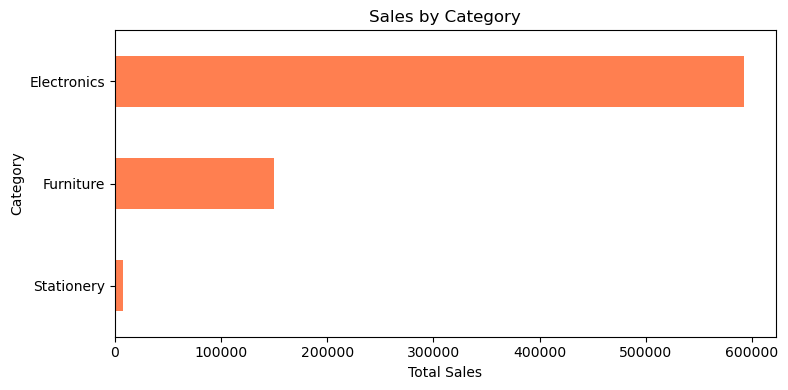

In [13]:
# Bar Chart - Sales by Category
cat_sales = df_clean.groupby('Category')['Total_Sales'].sum().sort_values()

cat_sales.plot(kind='barh', figsize=(8, 4), color='coral')
plt.title('Sales by Category')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

Electronics had the highest total sales, while Stationery had the lowest. The chart compares total sales across the product categories.

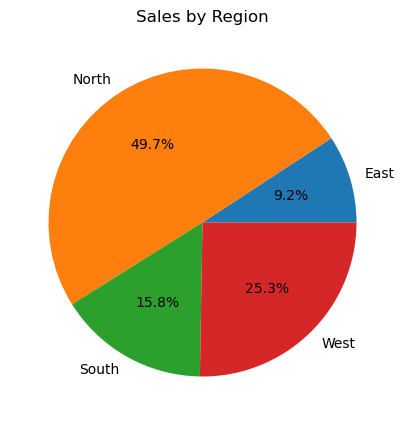

In [14]:
# Pie Chart - Sales by Region
region_sales = df_clean.groupby('Region')['Total_Sales'].sum()

plt.figure(figsize=(6, 5))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
plt.title('Sales by Region')
plt.savefig('region_sales.png')
plt.show()

North contributed the largest share of total sales, while East contributed the smallest. The pie chart shows how sales were divided among the regions.

## Section 5 — Seaborn Charts

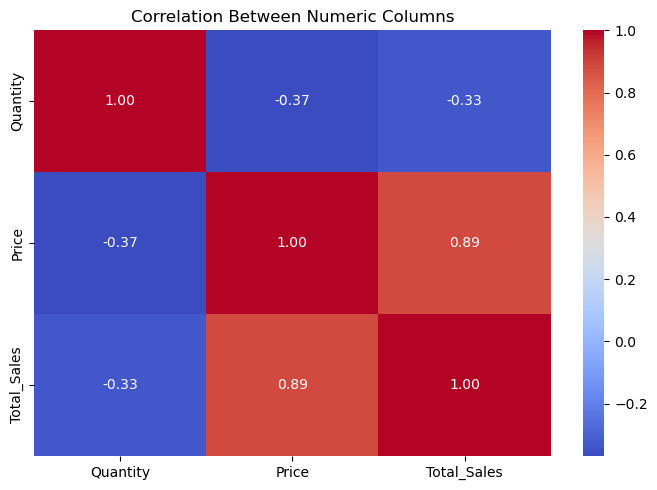

In [15]:
#  Correlation Heatmap

corr = df_clean.select_dtypes(include='number').corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Columns')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

Price and Total_Sales have the strongest relationship, with a correlation of about 0.89. This is a strong positive relationship, so higher prices tend to be associated with higher total sales in this dataset.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15820\1144875262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Category", y="Total_Sales", palette="Set2")


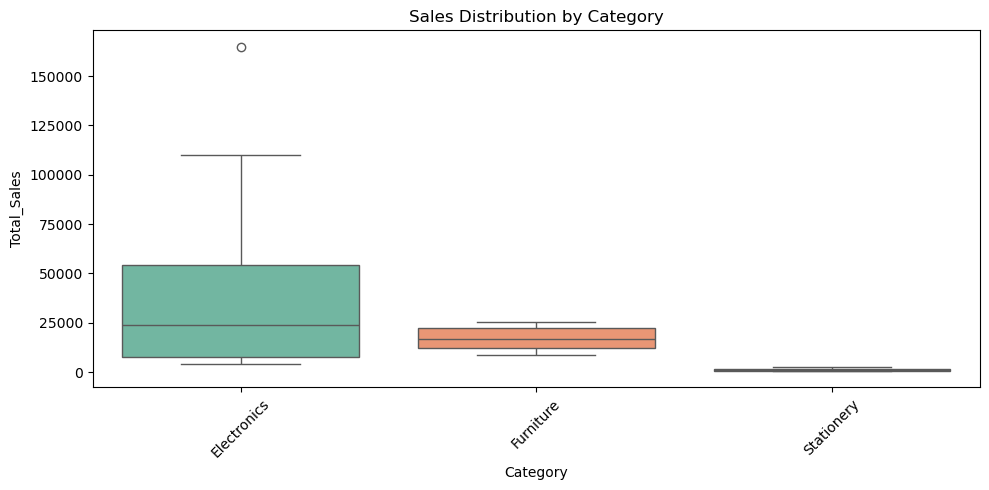

In [16]:
# Boxplot — Sales Distribution by Category

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="Category", y="Total_Sales", palette="Set2")
plt.title("Sales Distribution by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot.png")
plt.show()

Electronics shows the greatest variation in Total_Sales, with a much wider spread than Furniture or Stationery. The boxplot shows a high outlier in Electronics, no outliers are visible for the other categories.

## Section 6 — EDA Report

In [17]:
# Top and Bottom Products  

products = df_clean.groupby("Product")["Total_Sales"].sum().sort_values()

print("Bottom 3:")
print(products.head(3))

print("Top 3:")
print(products.tail(3))

Bottom 3:
Product
Pen          1900
Notebook     5400
Mouse       18400
Name: Total_Sales, dtype: int64
Top 3:
Product
Printer     60000
Monitor    162000
Laptop     330000
Name: Total_Sales, dtype: int64


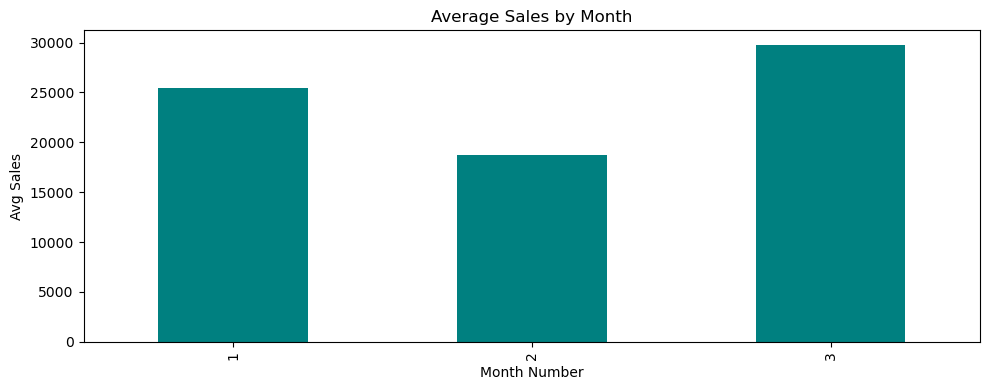

In [18]:
#  Analyzing Seasonal Pattern

df_clean['Month_Num'] = df_clean['Date'].dt.month
seasonal = df_clean.groupby('Month_Num')['Total_Sales'].mean()

seasonal.plot(kind='bar', figsize=(10, 4), color='teal')
plt.title('Average Sales by Month')
plt.xlabel('Month Number')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('seasonal.png')
plt.show()


## KEY FINDINGS

1. Electronics generated 592,900, or 79.03% of total sales.
   Meaning: The business depends heavily on one category.
   Action: Test promotions to grow Furniture and Stationery sales.

2. March had the highest monthly total at 327,200. Across its 11 sales, the average sale was 29,745.45—about 20.72% above the average of the three monthly averages, 24,640.34.
   Meaning: March was the strongest month in this January–March dataset.
   Action: Investigate what drove March sales before making seasonal plans.

3. The top 3 products were Laptop (330,000), Monitor (162,000), and Printer (60,000). The bottom 3 were Pen (1,900), Notebook (5,400), and Mouse (18,400).
   Meaning: Sales vary considerably by product.
   Action: Keep top-selling products available and test promotions for lower-selling products.

4. R-squared was unavailable because the model had only 3 monthly data points and 1 test month.
   Meaning: This result cannot tell us reliably whether sales follow a seasonal pattern.
   Action: Collect more months of data before relying on a sales forecast.

5. The classifier used Quantity and Month_Num and had a High-sale F1-score of 0.80 on 6 test records; it identified 2 of the 3 actual High sales.
   Meaning: These features show some predictive signal, but the test sample is small.
   Action: Validate with more records and test whether adding Price improves predictions.

## RECOMMENDATIONS

1. Maintain stock for Electronics’ best-selling products, especially Laptop and Monitor, while testing promotions for Furniture and Stationery.
2. Collect at least 12 months of sales data before making seasonal plans or relying on a sales forecast.

### Distribution and Hypothesis Testing

Skewness: 2.695
25th pct: 6100.0
75th pct: 24000.0


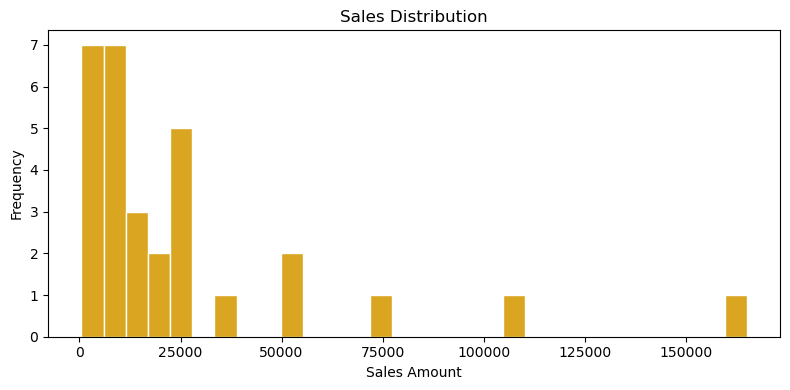

In [19]:
# Distribution and Percentiles

sales = df_clean["Total_Sales"]

print("Skewness:", round(sales.skew(), 3))
print("25th pct:", round(np.percentile(sales, 25), 2))
print("75th pct:", round(np.percentile(sales, 75), 2))

plt.figure(figsize=(8, 4))
plt.hist(sales, bins=30, color="goldenrod", edgecolor="white")
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("distribution.png")
plt.show()

In [20]:
# T-Test

cat_a = df_clean.loc[
    df_clean["Category"] == "Electronics", "Total_Sales"
]
cat_b = df_clean.loc[
    df_clean["Category"] == "Furniture", "Total_Sales"
]

t_stat, p_val = stats.ttest_ind(cat_a, cat_b)

print("Electronics rows:", len(cat_a))
print("Furniture rows:", len(cat_b))
print("T-stat:", round(t_stat, 3))
print("P-value:", round(p_val, 4))

if p_val < 0.05:
    print("The sales difference is statistically significant.")
else:
    print("The sales difference is not statistically significant.")

Electronics rows: 15
Furniture rows: 9
T-stat: 1.463
P-value: 0.1577
The sales difference is not statistically significant.


This dataset does not provide strong evidence that Electronics and Furniture sales differ. The small number of rows means the result may be uncertain.

## Section 7 — Linear Regression

In [21]:
# Averages aur train-test split

monthly_df = (
    df_clean.groupby("Month_Num")["Total_Sales"]
    .mean()
    .reset_index()
)

X = monthly_df[["Month_Num"]]
y = monthly_df["Total_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Monthly data points:", len(monthly_df))
print("Test data points:", len(X_test))

Monthly data points: 3
Test data points: 1


In [22]:
# Train and Evaluate

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))

if len(y_test) >= 2:
    print("R-squared:", round(r2_score(y_test, y_pred), 3))
else:
    print("R-squared: Not available (test set has only 1 month)")


MAE: 17654.34
R-squared: Not available (test set has only 1 month)


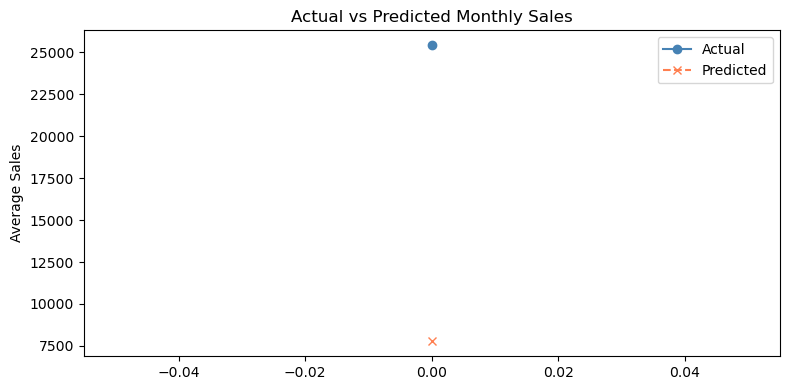

In [23]:
# Plot Actual vs Predicted

plt.figure(figsize=(8, 4))
plt.plot(y_test.values, label="Actual", marker="o", color="steelblue")
plt.plot(y_pred, label="Predicted", marker="x", linestyle="--", color="coral")
plt.title("Actual vs Predicted Monthly Sales")
plt.ylabel("Average Sales")
plt.legend()
plt.tight_layout()
plt.savefig("regression.png")
plt.show()

Interpretation :-

The model's MAE is 17,654.34. This is the average prediction error for the test data. R-squared could not be evaluated because the test set contains only one month. This dataset has only three months, so the model's performance cannot be judged reliably.

## Section 8 — Classification


In [24]:
# High and low

median_sales = df_clean["Total_Sales"].median()
df_clean["High_Sale"] = (df_clean["Total_Sales"] > median_sales).astype(int)

print("High:", df_clean["High_Sale"].sum())
print("Low:", (df_clean["High_Sale"] == 0).sum())

High: 14
Low: 16


In [25]:
# Train the Model

X = df_clean[['Quantity', 'Month_Num']]
y = df_clean['High_Sale']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


              precision    recall  f1-score   support

         Low       0.75      1.00      0.86         3
        High       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



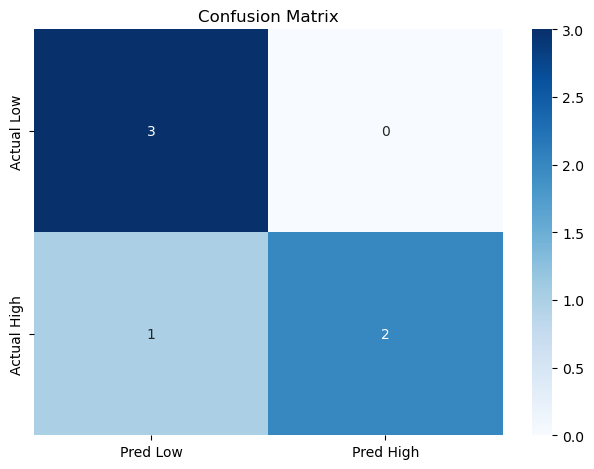

In [26]:
# Evaluate the Model

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Low", "High"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Low", "Pred High"],
    yticklabels=["Actual Low", "Actual High"]
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

The model's F1-score for High sales is 0.80. It missed 1 of the 3 actual High sales by predicting it as Low, and it did not incorrectly label any Low sales as High. The test set contains only 6 records, so the score may change with more data.